In [12]:
import sys
from pathlib import Path

PROJECT_ROOT = str(Path.cwd().parent.resolve())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import a_mps_Gio, b_model_Gio, c_tebd_Gio
import numpy as np
from scipy.linalg import svd
import importlib 
import matplotlib.pyplot as plt
#from tqdm import tqdm

In [13]:
import pickle

with open("simulations/ferro/L55_sigmay_n12_dt0.01_g0.15_J1.0_k0.1_h0_chi200/Corr.pkl", "rb") as f:
    Corr_ferro = pickle.load(f)

with open("simulations/ferro/L55_sigmay_n12_dt0.01_g0.15_J1.0_k0.1_h0_chi200/S.pkl", "rb") as f:
    S_ferro = pickle.load(f)

Plot of Correlation Function

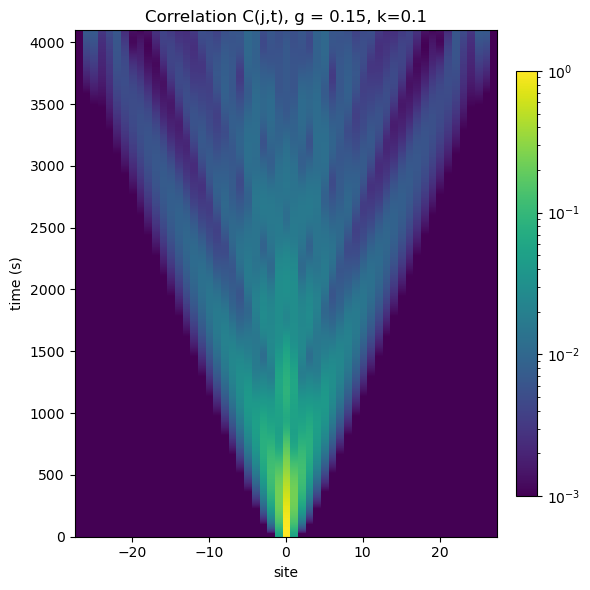

In [15]:
from matplotlib.colors import LogNorm
L=55
n=12
N=2**n
g = 0.15
k = 0.1

fig, ax = plt.subplots(figsize = (6,6))
data = np.abs(Corr_ferro)
im = ax.imshow(data, norm=LogNorm(#vmin=data.min(), 
                                  vmin=10**-3,
                                  vmax=data.max()),
                       aspect='auto', interpolation='none', origin='lower',
                       extent=[-(L//2)-0.5, L//2+0.5, 0, N])
# im = ax.imshow(data, aspect='auto', interpolation='none', origin = 'lower',  extent = [-(L//2)-0.5, L//2+0.5, 0, N],)
fig.colorbar(im, fraction=0.046, pad=0.04)  # Add colorbar
ax.set_title(f'Correlation C(j,t), g = {g}, k={k}')
ax.set(xlabel = 'site', ylabel = 'time (s)')
# ax.set(ylim=[0,3000])
# ax.plot(np.linspace(0,L//2+0.5,100), np.linspace(0,850,100))
# ax.plot(np.linspace(0,-L//2+0.5,100), np.linspace(0,850,100))
plt.tight_layout()

## Part b 

- Write another function that performs a Fourier transformation in space and time to obtain the dynamic structure factor $S(k, \omega)$:

$$
S(k, \omega) = \sum^{L−1}_{j=0} \sum^N_{t_n = 0}e^{i\omega \delta t \cdot t_n − i k \cdot j} C(\Delta t \cdot t_n, j) · G(tn)
$$


- Remember to multiply the signal with a Gaussian window function G(tn) in order to avoid Gibbs oscillations from the Fourier transform of the finite time data (cf. equation (7)).

In [42]:
import FourierTransform as FT
importlib.reload(FT)

<module 'FourierTransform' from '/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/FourierTransform.py'>

Now we have found C(t,j)= C_t,j which is a matrix (list) with each row corresponding to a specific time step where correlation function is evaluated for each site j (for sigmay_j) 

In [28]:
Corr_ferro = np.array(Corr_ferro)

In [29]:
Swk_ferro, momenta_ferro, freqs_ferro = FT.get_Swk(Corr_ferro, L = 55, dt = 0.01)

Compute Fourier transform
finished


# Part c: 
Obtain S(k,w) and plot it

2048
(55,)
55


/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/FourierTransform.py:227: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  


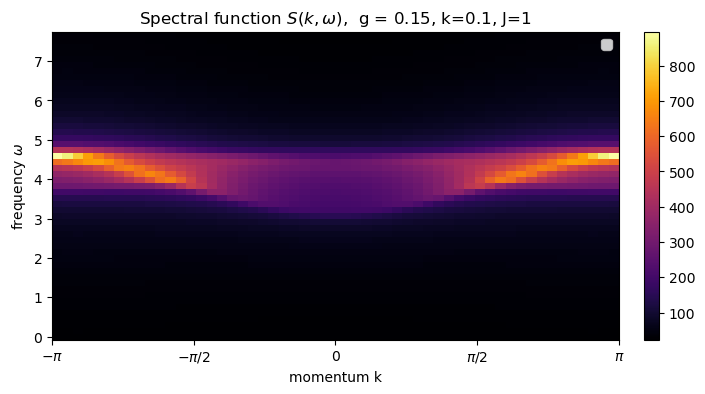

In [44]:
FT.plot_Swk(Swk_ferro, momenta_ferro, freqs_ferro, g=0.15, J=1, interval=50, 
            x_tick_every=None, 
            title = r'Spectral function $S(k, \omega)$,  g = 0.15, k=0.1, J=1',
            )

### $S(k,\omega)$ at g= 0.2 and h = 0.1

In [ ]:
S_new, Corr_new = correlation_Ctj(L = 60, J = 1.,g = 0.2, X = sigmay, Y = sigmay, T = 80, dt = 0.001, h = 0.1)

finite TEBD, (imaginary time evolution)
L=60, J=1.0, g=0.20, h = 0.1
dt = 0.10000: E = -65.5896394275749
dt = 0.01000: E = -65.5898141768567
dt = 0.00100: E = -65.5898328433591
dt = 0.00010: E = -65.5898347205633
dt = 0.00001: E = -65.5898349083083
final bond dimensions:  [2, 4, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 4, 2]


KeyboardInterrupt: 

Compute Fourier transform


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


finished
199999
(51,)
51


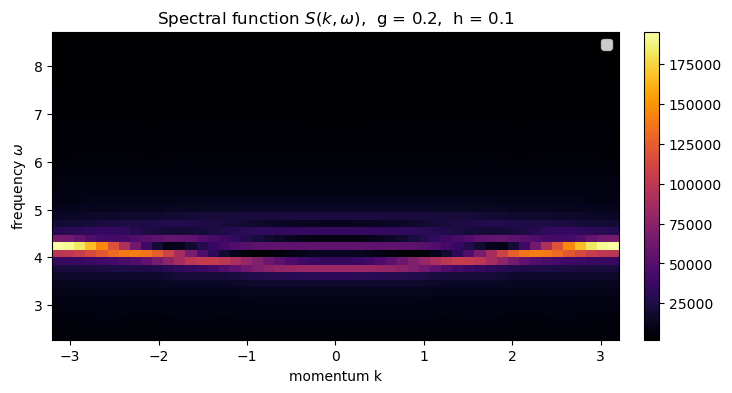

In [ ]:
Corr_new = np.array(Corr_new)
Swk_new, momenta_new, freqs_new = FT.get_Swk(Corr_new, L = 60, dt = 0.001)
FT.plot_Swk(Swk_new, momenta_new, freqs_new, title = r'Spectral function $S(k, \omega)$,  g = 0.2,  h = 0.1', offset=15, interval=40)

PUNTO PRINCIPALE del colloquium: capire la fisica di quello che si sta vedendo!